In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
borismarjanovic_price_volume_data_for_all_us_stocks_etfs_path = kagglehub.dataset_download('borismarjanovic/price-volume-data-for-all-us-stocks-etfs')

print('Data source import complete.')


100%|██████████| 492M/492M [00:18<00:00, 28.2MB/s]

Extracting files...


## Getting started

In [ ]:

import numpy as np
import pandas as pd
import gc
import os
import random
import copy
import matplotlib.pyplot as plt
import pandas
import statsmodels
from statsmodels.tsa.stattools import adfuller

We'll analyze the closing price of AMZN stocks, but in practice you apply the same principles to any other timeseries

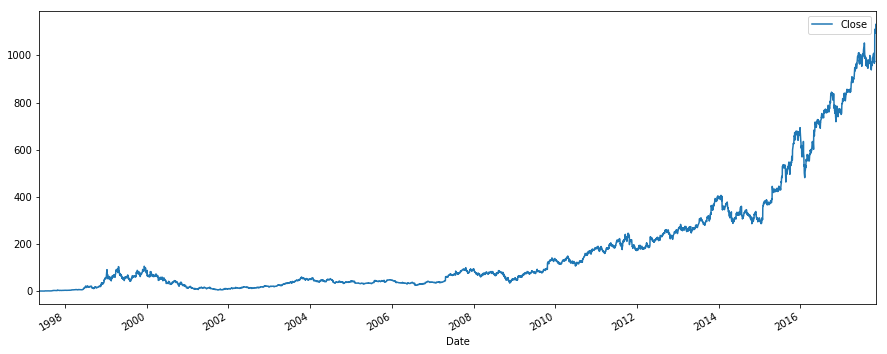

In [ ]:
dateparse = lambda dates: pd.datetime.strptime(dates, '%Y-%m-%d')
df=pd.read_csv('/kaggle/input/price-volume-data-for-all-us-stocks-etfs/Data/Stocks/amzn.us.txt',parse_dates=['Date'],index_col=['Date'],date_parser=dateparse)
df=df.drop(columns=['Open','High','Low','Volume','OpenInt'])
df.plot(figsize=(15,6))
plt.show()

Usually univariate time series analysis is done on a stationary series, so first off we'll check for stationarity using the ADF test

In [ ]:
adftest=adfuller(df['Close'])
print('ADF Statistic: %f' % adftest[0])
print('ADF p-value: %f' % adftest[1])

ADF Statistic: 4.573103
ADF p-value: 1.000000


We cannot reject the null hypothesis of non-stationarity. A popular way to try and circumvent this is to use the logarithm of the original series, so lets see how that works out.

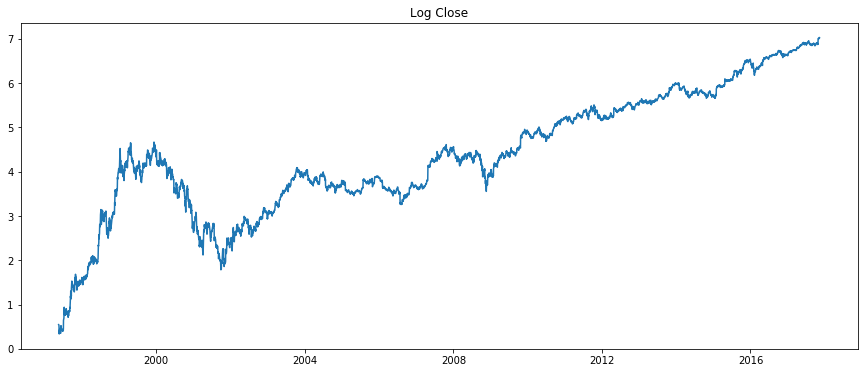

In [ ]:
df_log=pd.DataFrame(np.log(df['Close']),index=df.index)
plt.figure(figsize=(15,6))
plt.plot(df_log)
plt.title('Log Close')
plt.show()

In [ ]:
adftest=adfuller(df_log['Close'])
print('ADF Statistic: %f' % adftest[0])
print('ADF p-value: %f' % adftest[1])

ADF Statistic: -1.946347
ADF p-value: 0.310582


## Traditional Differencing

The log of the series was also non-stationary, usually at this point one then differences the series or the log of the series, (hence changing the variable of analysis to the returns or log returns of the stock) so lets see how this works out

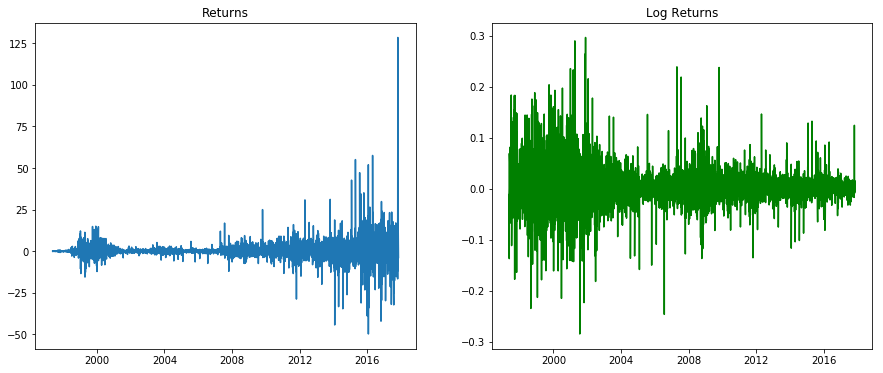

In [ ]:
df['Returns']=df['Close']-df['Close'].shift(1)
df_log['Log_Returns']=df_log['Close']-df_log['Close'].shift(1)
plt.figure(figsize=(15,6))
plt.subplot(1,2,1)
plt.plot(df['Returns'])
plt.title('Returns')
plt.subplot(1,2,2)
plt.plot(df_log['Log_Returns'],'g-')
plt.title('Log Returns')
plt.show()

I'm not a particular fan of discretionary graphical analysis, so let's check both of our new series through the ADF test.

In [ ]:
adftest_ret=adfuller(df['Returns'].dropna())
print('Returns ADF Statistic: %f' % adftest_ret[0])
print('Returns ADF p-value: %f' % adftest_ret[1])
adftest_lret=adfuller(df_log['Log_Returns'].dropna())
print('Log-Returns ADF Statistic: %f' % adftest_lret[0])
print('Log-Returns ADF p-value: %f' % adftest_lret[1])

Returns ADF Statistic: -10.979058
Returns ADF p-value: 0.000000
Log-Returns ADF Statistic: -12.174476
Log-Returns ADF p-value: 0.000000


And *voilá*, we have stationary series that we can now work with for our forecasts. Or so we would usually say, but to me it seems that we might have *over* differentiated the series. As we can see the ADF p-value went from very high, to practically **zero**, which makes me think that maybe we can apply some level of differencing between 0 and 1, making sure the series is as stationary as we need it to be, but not more, because in the end differencing extracts mathematical memory from a series, and some memory is usually desirable in order to produce good forecasts. We'll use an approach called *fractional differencing*, which is explained in great detail on  [Marcos Lopez de Prado's *Advances in Financial Machine Learning*](https://www.amazon.com/Advances-Financial-Machine-Learning-Marcos/dp/1119482089).


## Fractional Differencing

When the differencing coefficient is fractional, the series needed to calculate one data point becomes infinite, so firstly we need to find the weights corresponding to all preceding observations, and then we'll establish a cutoff, which will truncate the amount of weights we finally keep. Usually such cutoff is very low, around $10^{-4}$ or so, in order to retain as much mathematical memory as possible. First off lets visualize how such weights would behave depending on the differencing order, which we will call $d$. (Credit for [Simon Kuttruf on github](https://gist.github.com/skuttruf/fb82807ab0400fba51c344313eb43466) as he's the author of the functions used to implement fractional differencing).

In [ ]:
def getWeights(d,lags):
    # return the weights from the series expansion of the differencing operator
    # for real orders d and up to lags coefficients
    w=[1]
    for k in range(1,lags):
        w.append(-w[-1]*((d-k+1))/k)
    w=np.array(w).reshape(-1,1)
    return w
def plotWeights(dRange, lags, numberPlots):
    weights=pd.DataFrame(np.zeros((lags, numberPlots)))
    interval=np.linspace(dRange[0],dRange[1],numberPlots)
    for i, diff_order in enumerate(interval):
        weights[i]=getWeights(diff_order,lags)
    weights.columns = [round(x,2) for x in interval]
    fig=weights.plot(figsize=(15,6))
    plt.legend(title='Order of differencing')
    plt.title('Lag coefficients for various orders of differencing')
    plt.xlabel('lag coefficients')
    #plt.grid(False)
    plt.show()
def ts_differencing(series, order, lag_cutoff):
    # return the time series resulting from (fractional) differencing
    # for real orders order up to lag_cutoff coefficients

    weights=getWeights(order, lag_cutoff)
    res=0
    for k in range(lag_cutoff):
        res += weights[k]*series.shift(k).fillna(0)
    return res[lag_cutoff:]

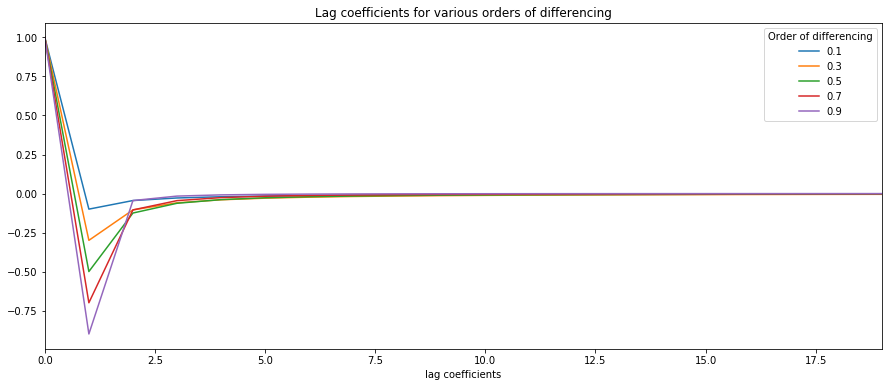

In [ ]:
plotWeights([0.1,0.9],20,5)

In the plot above we can get a feel of whats actually happening. The weight of the present value equals one, and with differencing order of $d=1$ we would have the coefficient of the first lag be exactly -1 and the rest would be zero. But since our differfencing order is fractional each of the lags has a weight, and they converge to zero in absolute value (faster convergence towards zero happens in higher orders of differencing), and so we must decide a *cutoff value* for the absolute value of the coefficients so our series is not theoretically *infinite*. Larger time series would allow smaller cutoff values in order to preserve more memory, it ends up being a trade-off between memory conservation and computational efficiency. In short time series however, you might want to stay away from low threshold values, since they can (and will) greatly diminish the size of your training set.

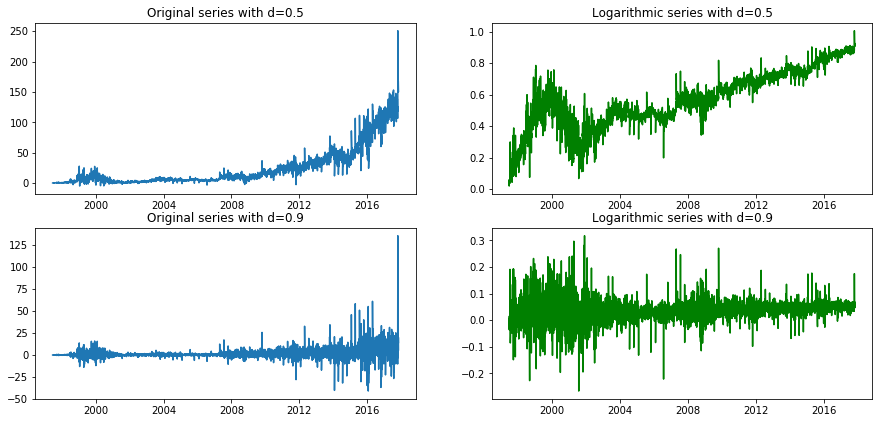

In [ ]:
differences=[0.5,0.9]
fig, axs = plt.subplots(len(differences),2,figsize=(15,6))
for i in range(0,len(differences)):
    axs[i,0].plot(ts_differencing(df['Close'],differences[i],20))
    axs[i,0].set_title('Original series with d='+str(differences[i]))
    axs[i,1].plot(ts_differencing(df_log['Close'],differences[i],20),'g-')
    axs[i,1].set_title('Logarithmic series with d='+str(differences[i]))
    plt.subplots_adjust(bottom=0.01) #increasing space between plots for aestethics

Remember the cutoff we mentioned earlier? Yeah, we still need to find that for each of the orders of differencing to be used, or better yet, we could just create a function that finds the amount of lags needed to reach any certain cutoff with any given differencing coefficient.

In [ ]:
def cutoff_find(order,cutoff,start_lags): #order is our dearest d, cutoff is 1e-5 for us, and start lags is an initial amount of lags in which the loop will start, this can be set to high values in order to speed up the algo
    val=np.inf
    lags=start_lags
    while abs(val)>cutoff:
        w=getWeights(order, lags)
        val=w[len(w)-1]
        lags+=1
    return lags

First off, we will modify our current *ts_differencing* function, so instead of the amount of lags, it will take our cutoff value (from now on we'll call it $\tau$) as an input and automatically calculate the correspoding amount of lags:

In [ ]:
def ts_differencing_tau(series, order, tau):
    # return the time series resulting from (fractional) differencing
    lag_cutoff=(cutoff_find(order,tau,1)) #finding lag cutoff with tau
    weights=getWeights(order, lag_cutoff)
    res=0
    for k in range(lag_cutoff):
        res += weights[k]*series.shift(k).fillna(0)
    return res[lag_cutoff:]

And now lets visualize relationship between the ADF p-value and our fractional differencing order $d$

In [ ]:
#this part takes about 20 minutes to compute
possible_d=np.divide(range(1,100),100)
tau=1e-4
original_adf_stat_holder=[None]*len(possible_d)
log_adf_stat_holder=[None]*len(possible_d)

for i in range(len(possible_d)):
    original_adf_stat_holder[i]=adfuller(ts_differencing_tau(df['Close'],possible_d[i],tau))[1]
    log_adf_stat_holder[i]=adfuller(ts_differencing_tau(df_log['Close'],possible_d[i],tau))[1]

Text(0.5, 1.0, 'ADF P-value by differencing order in the logarithmic series')

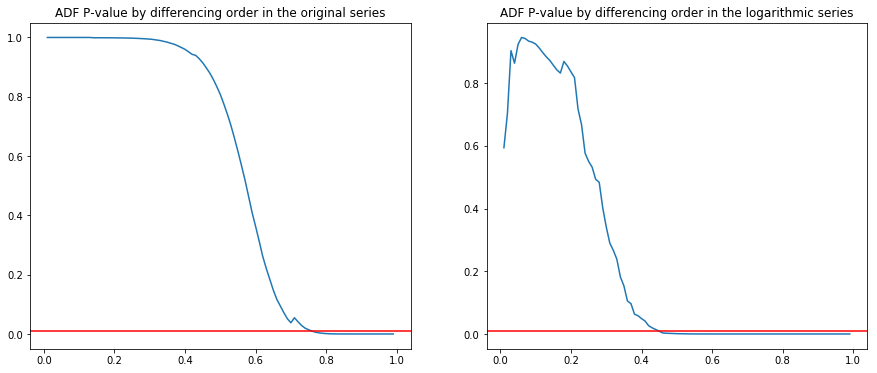

In [ ]:
#now the plots of the ADF p-values
fig, axs = plt.subplots(1,2,figsize=(15,6))
axs[0].plot(possible_d,original_adf_stat_holder)
axs[0].axhline(y=0.01,color='r')
axs[0].set_title('ADF P-value by differencing order in the original series')
axs[1].plot(possible_d,log_adf_stat_holder)
axs[1].axhline(y=0.01,color='r')
axs[1].set_title('ADF P-value by differencing order in the logarithmic series')

As we can see, the original series breaks the threshold of 0.01 for the ADF p-value with an order of differencing of about 0.7, and in the logarithmic series it happens at about 0.5, so we can surely say that taking a full difference in this case is not necessary to achieve stationarity. Using fractionally differenced variables as dependent variables or features for time series modelling could improve predictive performance in many cases because the time series is allowed to retain more memory while still being stationary, so be sure to give it a try.